In [1]:
import subprocess, os

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = '/kaggle/working/amr-5-class'
DATASET  = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

if os.path.exists(WORK_DIR):
    print("Repo already cloned — pulling latest")
    subprocess.run(['git', '-C', WORK_DIR, 'pull'], check=True)
else:
    print("Cloning repo ...")
    subprocess.run(['git', 'clone', REPO_URL, WORK_DIR], check=True)

os.chdir(WORK_DIR)
print(f"\nWorking directory: {os.getcwd()}")

for path in ['src/dataset.py', 'src/train.py', 'src/evaluate.py',
             'src/models/mcldnn.py', 'src/utils/mltools.py',
             'src/models/mcldnn_attention.py',
             'src/utils/attention_analysis.py',
             'src/evaluate_attention.py',
             'configs/exp_5class_attention.yaml']:
    status = '✓' if os.path.exists(path) else '✗ MISSING'
    print(f"  {status}  {path}")

Cloning repo ...


Cloning into '/kaggle/working/amr-5-class'...



Working directory: /kaggle/working/amr-5-class
  ✓  src/dataset.py
  ✓  src/train.py
  ✓  src/evaluate.py
  ✓  src/models/mcldnn.py
  ✓  src/utils/mltools.py
  ✓  src/models/mcldnn_attention.py
  ✓  src/utils/attention_analysis.py
  ✓  src/evaluate_attention.py
  ✓  configs/exp_5class_attention.yaml


In [2]:
import pickle, sys
sys.path.insert(0, WORK_DIR)

print(f"Loading dataset from: {DATASET}")
with open(DATASET, 'rb') as f:
    Xd = pickle.load(f, encoding='iso-8859-1')

all_mods = sorted(set(k[0] for k in Xd.keys()))
all_snrs = sorted(set(k[1] for k in Xd.keys()))

print(f"\nAll modulations : {all_mods}")
print(f"All SNRs        : {all_snrs}  ({len(all_snrs)} levels)")
print(f"\nSamples per (mod, snr): {Xd[(all_mods[0], all_snrs[0])].shape}")

TARGET_CLASSES = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
n_total = len(TARGET_CLASSES) * len(all_snrs) * 1000
print(f"\nTraining data (5 classes, ALL {len(all_snrs)} SNRs):")
print(f"  {len(TARGET_CLASSES)} classes × {len(all_snrs)} SNRs × 1000 = {n_total:,} total")
print(f"  Train: {int(n_total*0.6):,}  Val: {int(n_total*0.2):,}  Test: {int(n_total*0.2):,}")
del Xd

Loading dataset from: /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat

All modulations : ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
All SNRs        : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]  (20 levels)

Samples per (mod, snr): (1000, 2, 128)

Training data (5 classes, ALL 20 SNRs):
  5 classes × 20 SNRs × 1000 = 100,000 total
  Train: 60,000  Val: 20,000  Test: 20,000


In [4]:
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import keras
keras.mixed_precision.set_global_policy('float32')
print(f"Keras policy: {keras.mixed_precision.global_policy()}")

from src.models.mcldnn_attention import build_mcldnn_attention

model = build_mcldnn_attention(classes=5)
total_params = model.count_params()
print(f"\nTotal params: {total_params:,}")
print(f"Constraint (<300k): {'✓ PASS' if total_params < 300_000 else '✗ FAIL'}")
model.summary()
del model

2026-06-21 16:04:17.384020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782057857.572508      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782057857.626899      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782057858.101423      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782057858.101474      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782057858.101477      58 computation_placer.cc:177] computation placer alr

Keras policy: <DTypePolicy "float32">


I0000 00:00:1782057872.673651      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Total params: 244,341
Constraint (<300k): ✓ PASS


Model: "MCLDNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input2 (InputLayer) │ (None, 128, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input3 (InputLayer) │ (None, 128, 1)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_2 (Conv1D)    │ (None, 128, 50)   │        450 │ input2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_3 (Conv1D)    │ (None, 128, 50)   │        450 │ input3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_x2          │ (None, 1, 128,    │          0 │ conv1_2[0][0]     │
│ (Reshape)           │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_x3          │ (None, 1, 128,    │          0 │ conv1_3[0][0]     │
│ (Reshape)           │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input1 (InputLayer) │ (None, 2, 128, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 128,    │          0 │ reshape_x2[0][0], │
│ (Concatenate)       │ 50)               │            │ reshape_x3[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_1 (Conv2D)    │ (None, 2, 128,    │        850 │ input1[0][0]      │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 2, 128,    │     20,050 │ concatenate[0][0] │
│                     │ 50)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2, 128,    │          0 │ conv1_1[0][0],    │
│ (Concatenate)       │ 100)              │            │ conv2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv4 (Conv2D)      │ (None, 1, 124,    │    100,100 │ concatenate_1[0]… │
│                     │ 100)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_final       │ (None, 124, 100)  │          0 │ conv4[0][0]       │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 124, 100)  │          0 │ reshape_final[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ [(None, 124,      │     40,400 │ add[0][0],        │
│ (MultiHeadAttentio… │ 100), (None, 4,   │            │ add[0][0],        │
│                     │ 124, 124)]        │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 124, 100)  │          0 │ mha[0][0],        │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm           │ (None, 124, 100)  │        200 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_drop (Dropout) │ (None, 124, 100)  │          0 │ attn_norm[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn1 (Dense)        │ (None, 124, 256)  │     25,856 │ attn_drop[0][0] 

 Total params: 244,341 (954.46 KB)

 Trainable params: 244,341 (954.46 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
DATASET = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

print("="*60)
print("  Training MCLDNN-Attention on ALL 20 SNRs (-20 to +18 dB)")
print("="*60)

!python src/train.py \
    --config configs/exp_5class_attention.yaml \
    --datasetpath {DATASET}

import os
w = 'experiments/5class_attention/checkpoints/best_model.weights.h5'
print(f"\n{'✓' if os.path.exists(w) else '✗ MISSING'}  {w}")

  Training MCLDNN-Attention on ALL 20 SNRs (-20 to +18 dB)
2026-06-21 16:04:34.806215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782057874.830665     165 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782057874.838455     165 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782057874.857960     165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782057874.858003     165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782057874.85801

In [3]:
print("="*60)
print("  Training MCLDNN Baseline on ALL 20 SNRs (original, unmodified)")
print("="*60)

!python src/train.py \
    --config configs/exp_5class_baseline.yaml \
    --datasetpath {DATASET}

import os
w = 'experiments/5class_baseline/checkpoints/best_model.weights.h5'
print(f"\n{'✓' if os.path.exists(w) else '✗ MISSING'}  {w}")

  Training MCLDNN Baseline on ALL 20 SNRs (original, unmodified)
2026-06-21 18:05:57.836968: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782065158.007279     118 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782065158.056584     118 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782065158.443567     118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782065158.443614     118 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782065158

In [4]:
import os, sys, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
import keras, gc
import keras.backend as K

K.clear_session(); gc.collect()
sys.path.insert(0, '/kaggle/working/amr-5-class')
os.environ['KERAS_BACKEND'] = 'tensorflow'
os.chdir('/kaggle/working/amr-5-class')

from src.dataset import load_data, FIVE_CLASS
from src.models.mcldnn_attention import build_mcldnn_attention
from src.models.mcldnn import MCLDNN

DATASET = '/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'

# ── Load full dataset ONCE — both models trained with same seed=2016 ──────────
# Confirms identical, training-unseen test set for both models.
(mods, snrs, lbl), _, _, (X_test, Y_test), (_, _, test_idx) = load_data(
    DATASET, FIVE_CLASS, seed=2016
)
test_SNRs = np.array([lbl[test_idx[j]][1] for j in range(len(test_idx))])
ALL_SNRS  = sorted(set(test_SNRs))
print(f"Test set: {len(test_idx)} samples across {len(ALL_SNRS)} SNRs (unseen during training)")

def make_inputs(X):
    return [np.expand_dims(X, 3).astype('float32'),
            np.expand_dims(X[:,0,:], 2).astype('float32'),
            np.expand_dims(X[:,1,:], 2).astype('float32')]
inp_test = make_inputs(X_test)

# ── Load both models ──────────────────────────────────────────────────────────
model_configs = {
    'Baseline (LSTM)': {
        'weights': 'experiments/5class_baseline/checkpoints/best_model.weights.h5',
        'build'  : lambda: MCLDNN(classes=5),
        'color': '#1f77b4', 'marker': 'o',
    },
    'Attention': {
        'weights': 'experiments/5class_attention/checkpoints/best_model.weights.h5',
        'build'  : lambda: build_mcldnn_attention(classes=5),
        'color': '#d62728', 'marker': '^',
    },
}

model_accs = {}
for name, cfg in model_configs.items():
    if not os.path.exists(cfg['weights']):
        print(f"[SKIP] {name} — weights not found: {cfg['weights']}")
        continue
    K.clear_session(); gc.collect()
    m = cfg['build']()
    m.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    m.load_weights(cfg['weights'])
    accs = {}
    for snr in ALL_SNRS:
        mk = test_SNRs == snr
        accs[snr] = m.evaluate([b[mk] for b in inp_test], Y_test[mk],
                                verbose=0, batch_size=400)[1]
    model_accs[name] = {'accs': accs, 'params': m.count_params(),
                        'color': cfg['color'], 'marker': cfg['marker']}
    print(f"✓ {name} — {m.count_params():,} params — "
          f"mean acc (all SNRs): {np.mean(list(accs.values()))*100:.2f}%")

# ── Print full-SNR table ──────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  FULL-SNR COMPARISON (-20 to +18 dB) — same test set")
print(f"{'='*60}")
names = list(model_accs.keys())
print(f"  {'SNR':>6}", end='')
for n in names: print(f"  {n:>16}", end='')
print()
for snr in ALL_SNRS:
    print(f"  {snr:>5} dB", end='')
    for n in names:
        print(f"  {model_accs[n]['accs'][snr]*100:>15.2f}%", end='')
    print()
print(f"  {'─'*50}")
print(f"  {'Mean':>6}", end='')
for n in names:
    print(f"  {np.mean(list(model_accs[n]['accs'].values()))*100:>15.2f}%", end='')
print()

# ── Save full comparison CSV ──────────────────────────────────────────────────
os.makedirs('experiments/comparison_full', exist_ok=True)
if len(names) == 2:
    df_full = pd.DataFrame({
        'snr': ALL_SNRS,
        'acc_baseline':  [model_accs[names[0]]['accs'][s] for s in ALL_SNRS],
        'acc_attention': [model_accs[names[1]]['accs'][s] for s in ALL_SNRS],
    })
    df_full['delta'] = df_full['acc_attention'] - df_full['acc_baseline']
    df_full.to_csv('experiments/comparison_full/comparison_all_snrs.csv', index=False)
    print(f"\n[SAVED] experiments/comparison_full/comparison_all_snrs.csv")

# ── Now the -6 to +6 dB SUBSET (slice of the SAME test set, no retraining) ────
sub_snrs = [s for s in ALL_SNRS if -6 <= s <= 6]
print(f"\n{'='*60}")
print(f"  SUBSET COMPARISON: SNR -6 to +6 dB only (same test samples)")
print(f"{'='*60}")
print(f"  {'SNR':>6}", end='')
for n in names: print(f"  {n:>16}", end='')
print()
sub_rows = []
for snr in sub_snrs:
    print(f"  {snr:>5} dB", end='')
    row = {'snr': snr}
    for n in names:
        v = model_accs[n]['accs'][snr]
        row[f'acc_{n}'] = v
        print(f"  {v*100:>15.2f}%", end='')
    sub_rows.append(row)
    print()
print(f"  {'─'*50}")
print(f"  {'Mean':>6}", end='')
for n in names:
    mean_sub = np.mean([model_accs[n]['accs'][s] for s in sub_snrs])
    print(f"  {mean_sub*100:>15.2f}%", end='')
print()

df_sub = pd.DataFrame(sub_rows)
if len(names) == 2:
    df_sub['delta'] = df_sub[f'acc_{names[1]}'] - df_sub[f'acc_{names[0]}']
df_sub.to_csv('experiments/comparison_full/comparison_minus6_to_6.csv', index=False)
print(f"\n[SAVED] experiments/comparison_full/comparison_minus6_to_6.csv")

2026-06-21 18:32:17.064233: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782066737.088394      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782066737.096304      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782066737.115684      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782066737.115728      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782066737.115731      58 computation_placer.cc:177] computation placer alr

[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
Test set: 20000 samples across 20 SNRs (unseen during training)


I0000 00:00:1782066743.899218      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1782066746.059331    4434 cuda_dnn.cc:529] Loaded cuDNN version 91002


✓ Baseline (LSTM) — 404,401 params — mean acc (all SNRs): 59.80%


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1782066752.098659    4433 service.cc:152] XLA service 0x7c58f8037d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782066752.098693    4433 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-06-21 18:32:33.425251: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.20 = (f32[400,50,2,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[400,50,2,135]{3,2,1,0} %bitcast.1602, f32[50,50,1,8]{3,2,1,0} %bitcast.1609, f32[50]{0} %bitcast.1611), window={size=1x8}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata

✓ Attention — 244,341 params — mean acc (all SNRs): 61.23%

  FULL-SNR COMPARISON (-20 to +18 dB) — same test set
     SNR   Baseline (LSTM)         Attention
    -20 dB            33.00%            32.90%
    -18 dB            32.40%            30.90%
    -16 dB            33.00%            32.00%
    -14 dB            30.40%            31.70%
    -12 dB            28.60%            30.30%
    -10 dB            30.60%            27.60%
     -8 dB            28.90%            28.30%
     -6 dB            30.60%            32.40%
     -4 dB            45.40%            40.00%
     -2 dB            62.70%            57.20%
      0 dB            75.30%            76.00%
      2 dB            80.60%            83.40%
      4 dB            83.60%            88.10%
      6 dB            85.80%            88.80%
      8 dB            84.70%            90.20%
     10 dB            84.90%            90.90%
     12 dB            87.90%            92.70%
     14 dB            84.40%            90

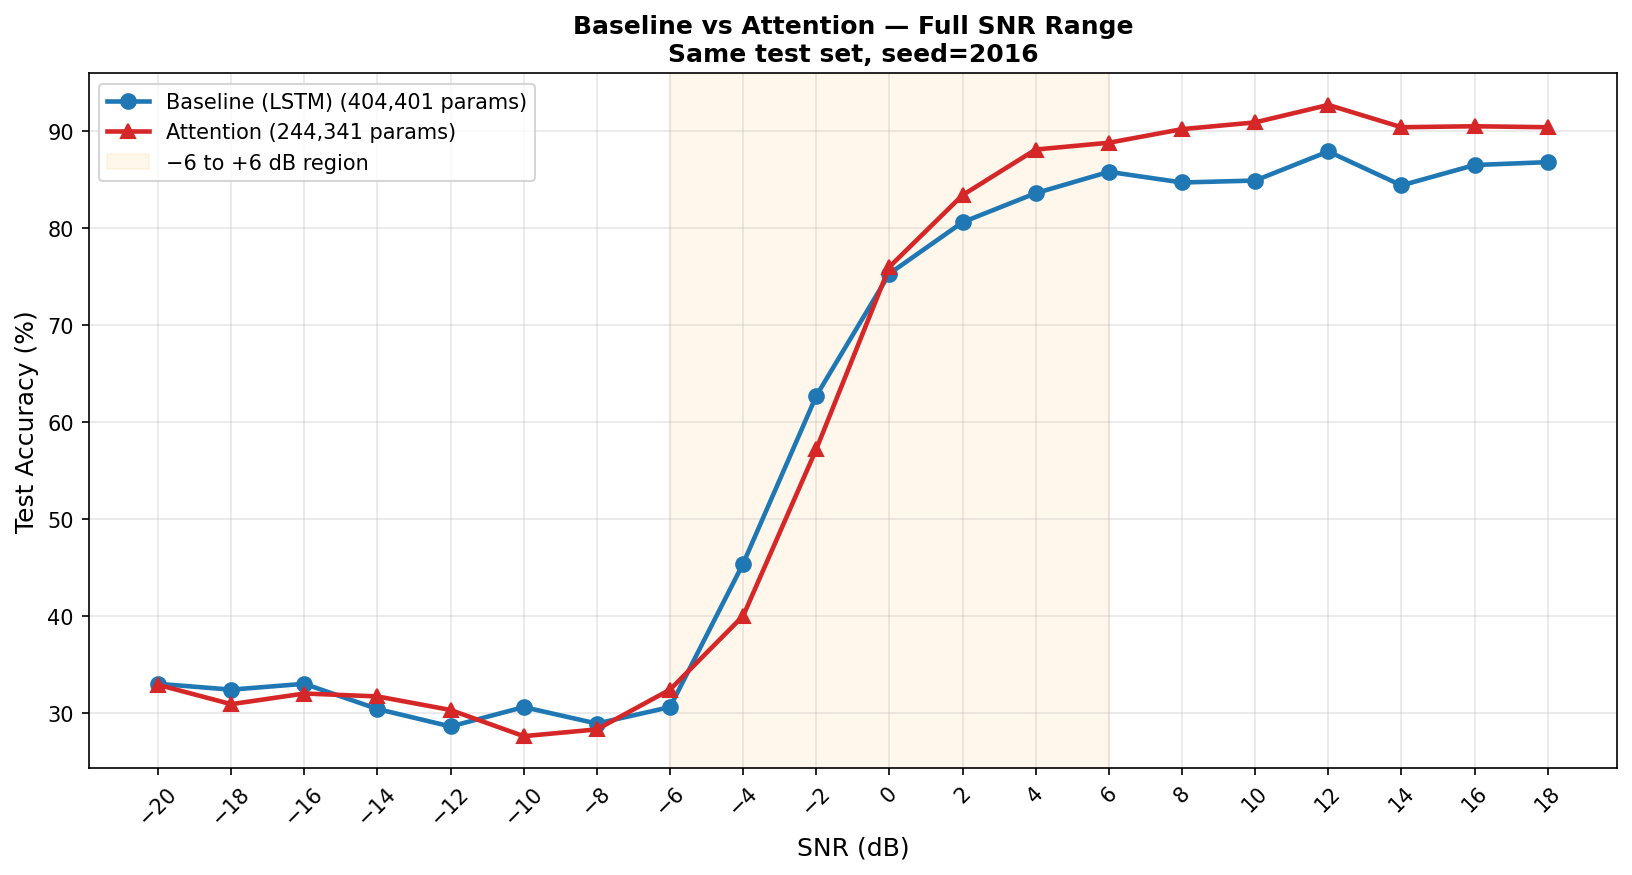

[SAVED] experiments/comparison_full/full_snr_comparison.png


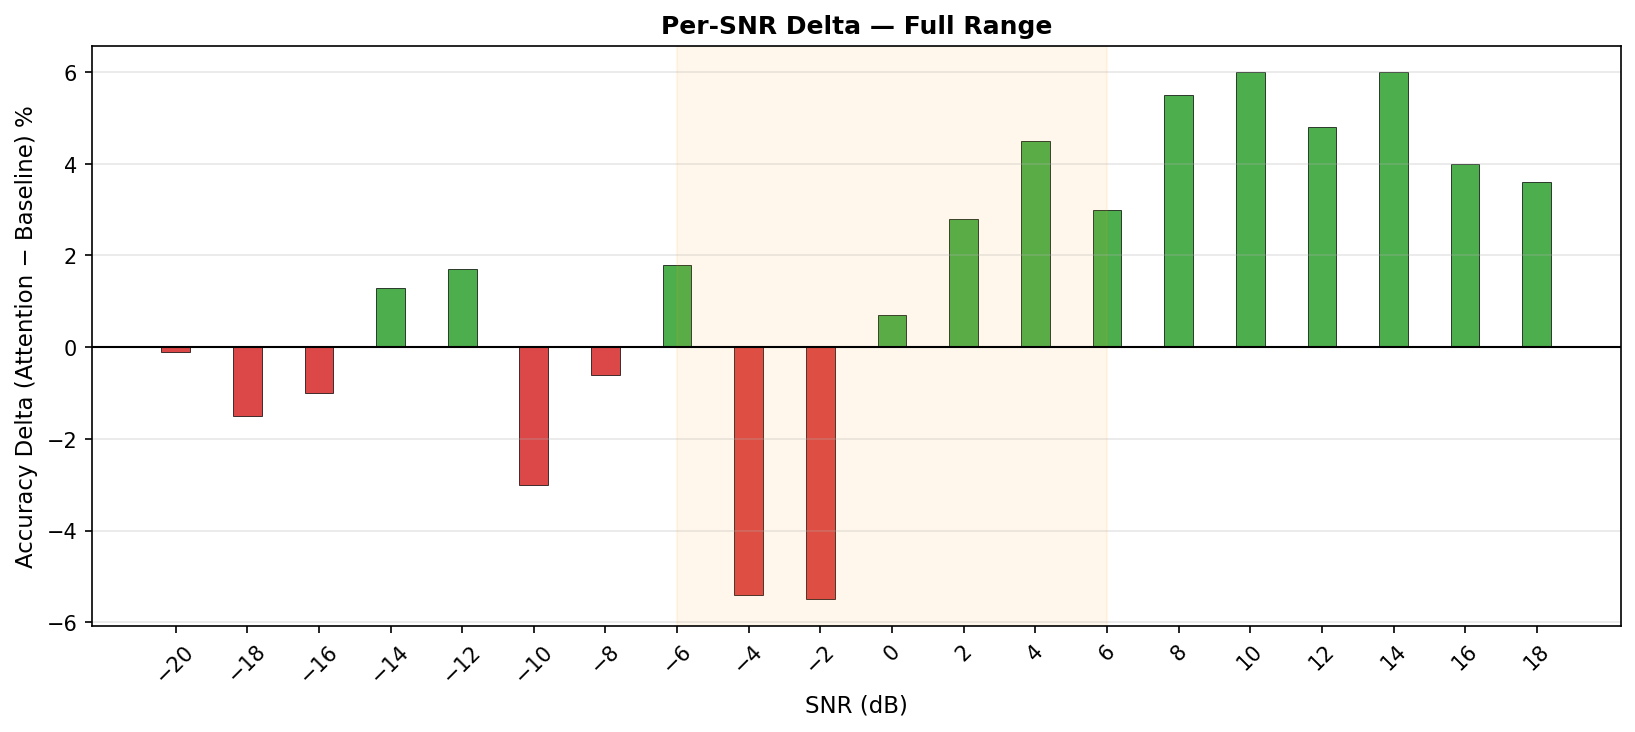

[SAVED] experiments/comparison_full/full_snr_delta.png


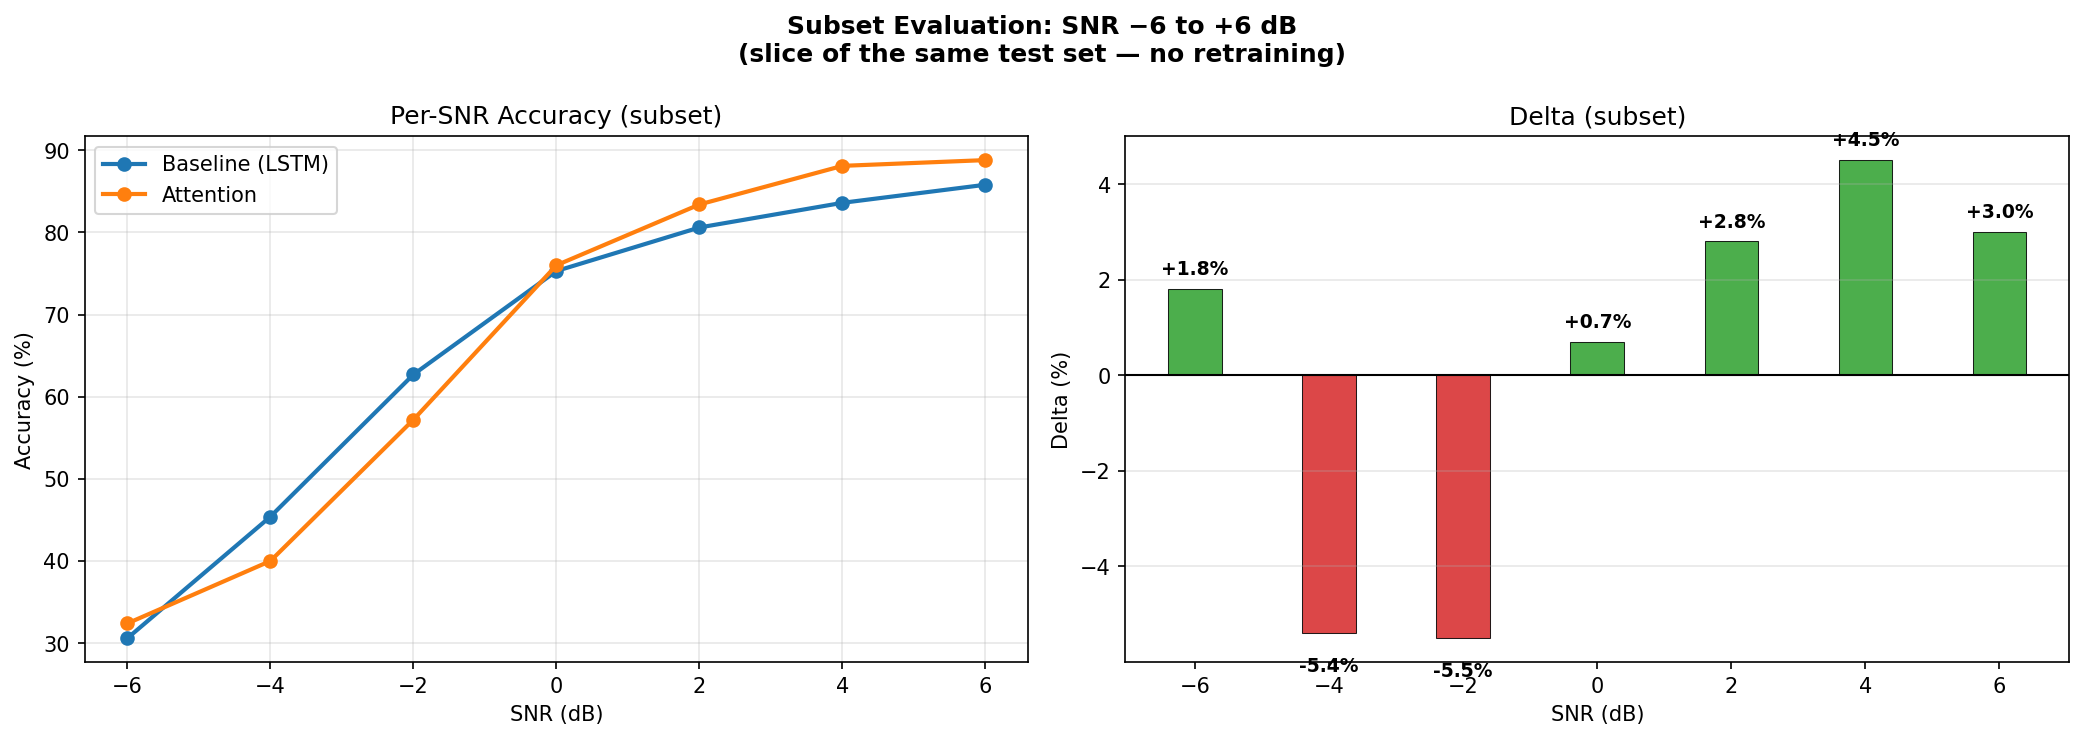

[SAVED] experiments/comparison_full/subset_minus6_to_6.png


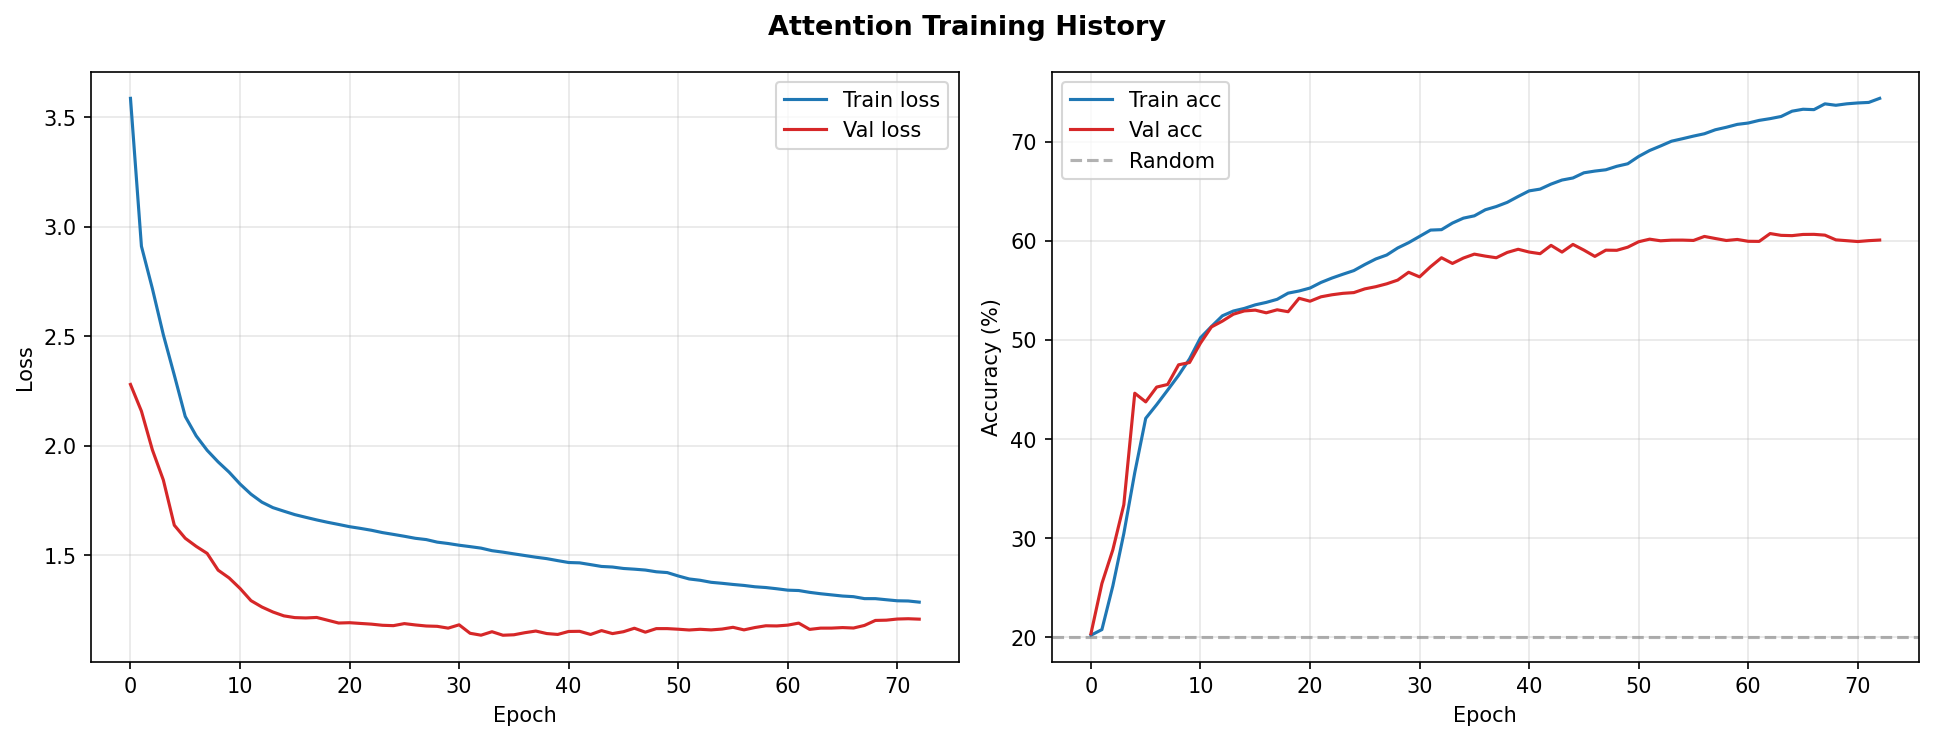

[SAVED] experiments/comparison_full/attention_training_history.png
  Best epoch: 34  val_loss=1.1337  val_acc=58.25%


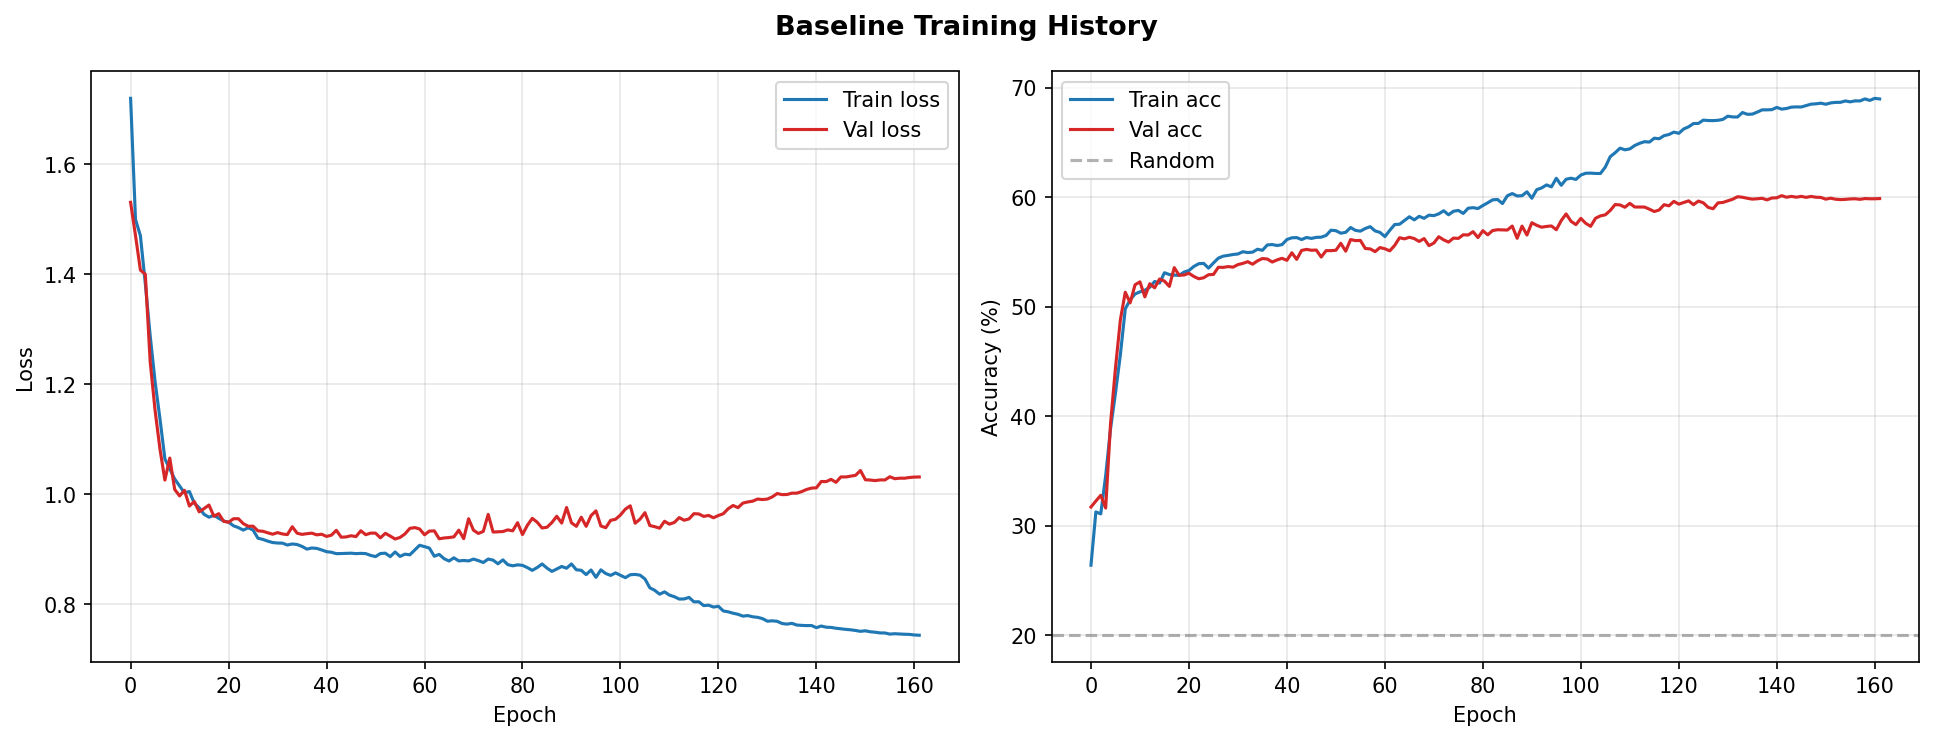

[SAVED] experiments/comparison_full/baseline_training_history.png
  Best epoch: 54  val_loss=0.9189  val_acc=56.04%


In [5]:
import os, numpy as np, pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.chdir('/kaggle/working/amr-5-class')
os.makedirs('experiments/comparison_full', exist_ok=True)

# ── Plot 1: Full SNR accuracy curves (both models) ────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
for name, r in model_accs.items():
    ys = [r['accs'][s]*100 for s in ALL_SNRS]
    ax.plot(ALL_SNRS, ys, marker=r['marker'], color=r['color'],
            linewidth=2.2, markersize=7, label=f"{name} ({r['params']:,} params)")
ax.axvspan(-6, 6, alpha=0.08, color='orange', label='−6 to +6 dB region')
ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Baseline vs Attention — Full SNR Range\nSame test set, seed=2016',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xticks(ALL_SNRS)
plt.xticks(rotation=45)
plt.tight_layout()
p1 = 'experiments/comparison_full/full_snr_comparison.png'
fig.savefig(p1, dpi=150, bbox_inches='tight')
plt.close()
display(Image(p1))
print(f"[SAVED] {p1}")

# ── Plot 2: Delta across full SNR range ───────────────────────────────────────
csv_full = 'experiments/comparison_full/comparison_all_snrs.csv'
if os.path.exists(csv_full):
    df = pd.read_csv(csv_full)
    fig, ax = plt.subplots(figsize=(11, 5))
    colors = ['#2ca02c' if d >= 0 else '#d62728' for d in df['delta']]
    ax.bar(df['snr'], df['delta']*100, color=colors, alpha=0.85,
           edgecolor='black', linewidth=0.4)
    ax.axhline(0, color='black', linewidth=1)
    ax.axvspan(-6, 6, alpha=0.08, color='orange')
    ax.set_xlabel('SNR (dB)', fontsize=11)
    ax.set_ylabel('Accuracy Delta (Attention − Baseline) %', fontsize=11)
    ax.set_title('Per-SNR Delta — Full Range', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticks(ALL_SNRS)
    plt.xticks(rotation=45)
    plt.tight_layout()
    p2 = 'experiments/comparison_full/full_snr_delta.png'
    fig.savefig(p2, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p2))
    print(f"[SAVED] {p2}")

# ── Plot 3: -6 to +6 dB subset comparison ─────────────────────────────────────
csv_sub = 'experiments/comparison_full/comparison_minus6_to_6.csv'
if os.path.exists(csv_sub):
    df_sub = pd.read_csv(csv_sub)
    acc_cols = [c for c in df_sub.columns if c.startswith('acc_')]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Subset Evaluation: SNR −6 to +6 dB\n(slice of the same test set — no retraining)',
                 fontsize=12, fontweight='bold')
    ax = axes[0]
    for col in acc_cols:
        label = col.replace('acc_', '')
        ax.plot(df_sub['snr'], df_sub[col]*100, marker='o', linewidth=2, label=label)
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Accuracy (%)')
    ax.set_title('Per-SNR Accuracy (subset)'); ax.legend(); ax.grid(alpha=0.3)
    ax = axes[1]
    bar_colors = ['#2ca02c' if d >= 0 else '#d62728' for d in df_sub['delta']]
    bars = ax.bar(df_sub['snr'], df_sub['delta']*100, color=bar_colors,
                  alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', linewidth=1)
    for bar, val in zip(bars, df_sub['delta']*100):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.3 if val>=0 else -0.8),
                f'{val:+.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_xlabel('SNR (dB)'); ax.set_ylabel('Delta (%)')
    ax.set_title('Delta (subset)'); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    p3 = 'experiments/comparison_full/subset_minus6_to_6.png'
    fig.savefig(p3, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p3))
    print(f"[SAVED] {p3}")

# ── Plot 4 & 5: training curves for both models ───────────────────────────────
for tag, logdir in [('Attention', 'experiments/5class_attention/logs'),
                    ('Baseline',  'experiments/5class_baseline/logs')]:
    log_path = f'{logdir}/training_log.csv'
    if not os.path.exists(log_path):
        print(f"[SKIP] {tag} log not found: {log_path}")
        continue
    log = pd.read_csv(log_path)
    acc_col     = next((c for c in log.columns if 'accuracy' in c and 'val' not in c), 'accuracy')
    val_acc_col = next((c for c in log.columns if 'val' in c and 'accuracy' in c), 'val_accuracy')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{tag} Training History', fontsize=13, fontweight='bold')
    axes[0].plot(log['epoch'], log['loss'], color='#1f77b4', label='Train loss')
    axes[0].plot(log['epoch'], log['val_loss'], color='#d62728', label='Val loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(log['epoch'], log[acc_col]*100, color='#1f77b4', label='Train acc')
    axes[1].plot(log['epoch'], log[val_acc_col]*100, color='#d62728', label='Val acc')
    axes[1].axhline(20, color='gray', linestyle='--', alpha=0.6, label='Random')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    p = f'experiments/comparison_full/{tag.lower()}_training_history.png'
    fig.savefig(p, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(p))
    print(f"[SAVED] {p}")
    best = log['val_loss'].idxmin()
    print(f"  Best epoch: {log.loc[best,'epoch']}  val_loss={log.loc[best,'val_loss']:.4f}  "
          f"val_acc={log.loc[best,val_acc_col]*100:.2f}%")

In [6]:
# Cell 9 — Download everything
import zipfile, glob, os
from datetime import datetime

os.chdir('/kaggle/working/amr-5-class')
ts      = datetime.now().strftime('%Y%m%d_%H%M')
zip_out = f'/kaggle/working/final_results_{ts}.zip'

include_dirs = [
    'experiments/5class_baseline',
    'experiments/5class_attention',
    'experiments/comparison_full',
]
exts = ('.png', '.csv', '.h5', '.txt', '.yaml')

with zipfile.ZipFile(zip_out, 'w', zipfile.ZIP_DEFLATED) as zf:
    for d in include_dirs:
        for f in glob.glob(f'{d}/**/*', recursive=True):
            if os.path.isfile(f) and f.endswith(exts):
                zf.write(f)
                print(f"  + {f}")

size = os.path.getsize(zip_out)/1e6
print(f"\n[DONE] {zip_out}  ({size:.1f} MB)")
print("Download from Kaggle Output panel on the right →")

  + experiments/5class_baseline/checkpoints/best_model.weights.h5
  + experiments/5class_baseline/results/test_score.csv
  + experiments/5class_baseline/results/acc_per_snr.csv
  + experiments/5class_baseline/logs/total_loss.png
  + experiments/5class_baseline/logs/val_acc.txt
  + experiments/5class_baseline/logs/total_acc.png
  + experiments/5class_baseline/logs/val_loss.txt
  + experiments/5class_baseline/logs/training_log.csv
  + experiments/5class_baseline/logs/train_acc.txt
  + experiments/5class_baseline/logs/train_loss.txt
  + experiments/5class_baseline/shap/task4_snr_temporal_profiles.png
  + experiments/5class_baseline/shap/task4_snr_temporal_profiles_robust.png
  + experiments/5class_baseline/shap/task4_dispersion_vs_snr_robust.png
  + experiments/5class_baseline/shap/task4_per_class_par_heatmap.png
  + experiments/5class_baseline/shap/task4_final_summary.png
  + experiments/5class_baseline/shap/task2_temporal_distribution.png
  + experiments/5class_baseline/shap/task4_full_